# Module A Report: Lightweight DBMS with B+ Tree Index

## Introduction
This project addresses efficient data storage and retrieval for database-style workloads. A B+ Tree index was implemented from scratch to support fast insert, update, delete, exact search, and range query operations while preserving sorted structure and balance.

To evaluate indexing benefits, performance is compared against a brute-force linear baseline (BruteForceDB). The report includes implementation summary, automated benchmarks, Graphviz tree visualizations, and conclusions.

In [1]:
from pathlib import Path
import sys
import json
import math
import io
import shutil
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image, clear_output

# Ensure plots render inside the notebook even if backend was set to Agg earlier
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
if 'agg' in matplotlib.get_backend().lower():
    plt.switch_backend('module://matplotlib_inline.backend_inline')

module_a_dir = Path.cwd()
if not (module_a_dir / 'database').exists() and (module_a_dir / 'Module_A' / 'database').exists():
    module_a_dir = module_a_dir / 'Module_A'

if str(module_a_dir) not in sys.path:
    sys.path.insert(0, str(module_a_dir))

db_dir = module_a_dir / 'database'
viz_dir = db_dir / 'visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB
from database.performance import BenchmarkConfig, PerformanceAnalyzer


display(Markdown(f'**Module_A path:** `{module_a_dir}`'))
display(Markdown(f'**Visualization output folder:** `{viz_dir}`'))

**Module_A path:** `c:\Users\Saharsh\Desktop\SEM 6\Git_Repos\College_Social_Media_DB\Module_A`

**Visualization output folder:** `c:\Users\Saharsh\Desktop\SEM 6\Git_Repos\College_Social_Media_DB\Module_A\database\visualizations`

## Implementation Details
The B+ Tree uses separate internal and leaf node behavior:
- Internal nodes store separator keys and child pointers.
- Leaf nodes store actual key-value records and are linked left-to-right using `next` pointers for efficient range scans.
- Insertion triggers automatic splits and root growth when needed.
- Deletion handles underflow via sibling borrowing or merging.

The baseline BruteForceDB stores records in a linear list and performs operations by iteration, making it suitable for performance comparison.

In [2]:
# Core functionality test for B+ Tree
tree = BPlusTree(order=4)
records = [(15, 'u15'), (3, 'u3'), (8, 'u8'), (22, 'u22'), (7, 'u7'), (30, 'u30'), (1, 'u1'), (12, 'u12')]
for k, v in records:
    tree.insert(k, v)

print('Search key 12 ->', tree.search(12))
print('Search key 99 ->', tree.search(99))
print('Range [5, 22] ->', tree.range_query(5, 22))
deleted_8 = tree.delete(8)
print('Delete key 8 ->', deleted_8)
print('All records after delete ->', tree.get_all())

assert tree.search(12) == 'u12'
assert tree.search(99) is None
assert deleted_8 is True

Search key 12 -> u12
Search key 99 -> None
Range [5, 22] -> [(7, 'u7'), (8, 'u8'), (12, 'u12'), (15, 'u15'), (22, 'u22')]
Delete key 8 -> True
All records after delete -> [(1, 'u1'), (3, 'u3'), (7, 'u7'), (12, 'u12'), (15, 'u15'), (22, 'u22'), (30, 'u30')]


## Performance Analysis
This section benchmarks B+ Tree vs BruteForceDB over multiple dataset sizes and operations:
- insertion
- search
- deletion
- range query
- random mixed workload
- memory usage (peak bytes via `tracemalloc`)


In [ ]:
# Load consolidated benchmark results from JSON 
results_json_path = viz_dir / 'benchmark_results.json'
if not results_json_path.exists():
    raise FileNotFoundError(f'Expected benchmark JSON not found: {results_json_path}')

with open(results_json_path, 'r') as f:
    benchmark_results = json.load(f)

# Build the same row format previously produced by analyzer.to_table_rows
rows = []
for result in benchmark_results['results']:
    bplus = result['bplustree']
    brute = result['bruteforce']
    rows.append({
        'engine': 'bplustree',
        'size': result['size'],
        'insert_sec': bplus['insert_time_sec'],
        'search_sec': bplus['search_time_sec'],
        'delete_sec': bplus['delete_time_sec'],
        'range_sec': bplus['range_query_time_sec'],
        'mixed_sec': bplus['random_workload_time_sec'],
        'peak_memory_kib': bplus['peak_memory_bytes'] / 1024.0,
    })
    rows.append({
        'engine': 'bruteforce',
        'size': result['size'],
        'insert_sec': brute['insert_time_sec'],
        'search_sec': brute['search_time_sec'],
        'delete_sec': brute['delete_time_sec'],
        'range_sec': brute['range_query_time_sec'],
        'mixed_sec': brute['random_workload_time_sec'],
        'peak_memory_kib': brute['peak_memory_bytes'] / 1024.0,
    })

print('Benchmark sizes:', benchmark_results['config']['sizes'])
print('Total rows in summary table:', len(rows))

header = f"{'Engine':<12} {'Size':>6} {'Insert(s)':>12} {'Search(s)':>12} {'Delete(s)':>12} {'Range(s)':>12} {'Mixed(s)':>12} {'Peak KiB':>12}"
print(header)
print('-' * len(header))
for row in rows:
    print(f"{row['engine']:<12} {row['size']:>6} {row['insert_sec']:>12.6f} {row['search_sec']:>12.6f} {row['delete_sec']:>12.6f} {row['range_sec']:>12.6f} {row['mixed_sec']:>12.6f} {row['peak_memory_kib']:>12.3f}")

Benchmark sizes: [100, 1100, 2100, 3100, 4100, 5100, 6100, 7100, 8100, 9100]
Total rows in summary table: 20
Engine         Size    Insert(s)    Search(s)    Delete(s)     Range(s)     Mixed(s)     Peak KiB
-------------------------------------------------------------------------------------------------
bplustree       100     0.000267     0.000032     0.000126     0.000051     0.000227       23.109
bruteforce      100     0.000327     0.000145     0.000047     0.000060     0.000130        1.391
bplustree      1100     0.004604     0.000381     0.001331     0.000433     0.004966      240.805
bruteforce     1100     0.027098     0.008821     0.005266     0.000636     0.003606        9.141
bplustree      2100     0.005330     0.000883     0.002497     0.001134     0.007116      459.500
bruteforce     2100     0.105230     0.036662     0.019029     0.001220     0.014678       23.820
bplustree      3100     0.011342     0.001072     0.004785     0.001790     0.015053      683.875
bruteforc

In [4]:
speedups = []
for r in benchmark_results['results']:
    b = r['bplustree']
    bf = r['bruteforce']
    speedups.append({
        'size': r['size'],
        'insert_speedup': bf['insert_time_sec'] / max(b['insert_time_sec'], 1e-12),
        'search_speedup': bf['search_time_sec'] / max(b['search_time_sec'], 1e-12),
        'delete_speedup': bf['delete_time_sec'] / max(b['delete_time_sec'], 1e-12),
        'range_speedup': bf['range_query_time_sec'] / max(b['range_query_time_sec'], 1e-12),
    })

print('Per-size speedup (BruteForce / B+Tree)')
for s in speedups:
    print(f"N={s['size']:>5} | Insert={s['insert_speedup']:.3f}x | Search={s['search_speedup']:.3f}x | Delete={s['delete_speedup']:.3f}x | Range={s['range_speedup']:.3f}x")

print('Average speedup (BruteForce / B+Tree)')
print('Insert :', round(sum(x['insert_speedup'] for x in speedups) / len(speedups), 3), 'x')
print('Search :', round(sum(x['search_speedup'] for x in speedups) / len(speedups), 3), 'x')
print('Delete :', round(sum(x['delete_speedup'] for x in speedups) / len(speedups), 3), 'x')
print('Range  :', round(sum(x['range_speedup'] for x in speedups) / len(speedups), 3), 'x')

Per-size speedup (BruteForce / B+Tree)
N=  100 | Insert=1.221x | Search=4.480x | Delete=0.375x | Range=1.165x
N= 1100 | Insert=5.886x | Search=23.121x | Delete=3.956x | Range=1.468x
N= 2100 | Insert=19.741x | Search=41.501x | Delete=7.621x | Range=1.077x
N= 3100 | Insert=20.096x | Search=69.363x | Delete=9.751x | Range=1.649x
N= 4100 | Insert=24.267x | Search=88.600x | Delete=11.548x | Range=6.185x
N= 5100 | Insert=22.954x | Search=113.824x | Delete=13.821x | Range=7.798x
N= 6100 | Insert=46.462x | Search=98.793x | Delete=16.729x | Range=1.131x
N= 7100 | Insert=49.760x | Search=153.949x | Delete=19.221x | Range=1.225x
N= 8100 | Insert=38.896x | Search=157.321x | Delete=19.561x | Range=1.115x
N= 9100 | Insert=45.704x | Search=152.193x | Delete=30.464x | Range=1.136x
Average speedup (BruteForce / B+Tree)
Insert : 27.499 x
Search : 90.314 x
Delete : 13.305 x
Range  : 2.395 x


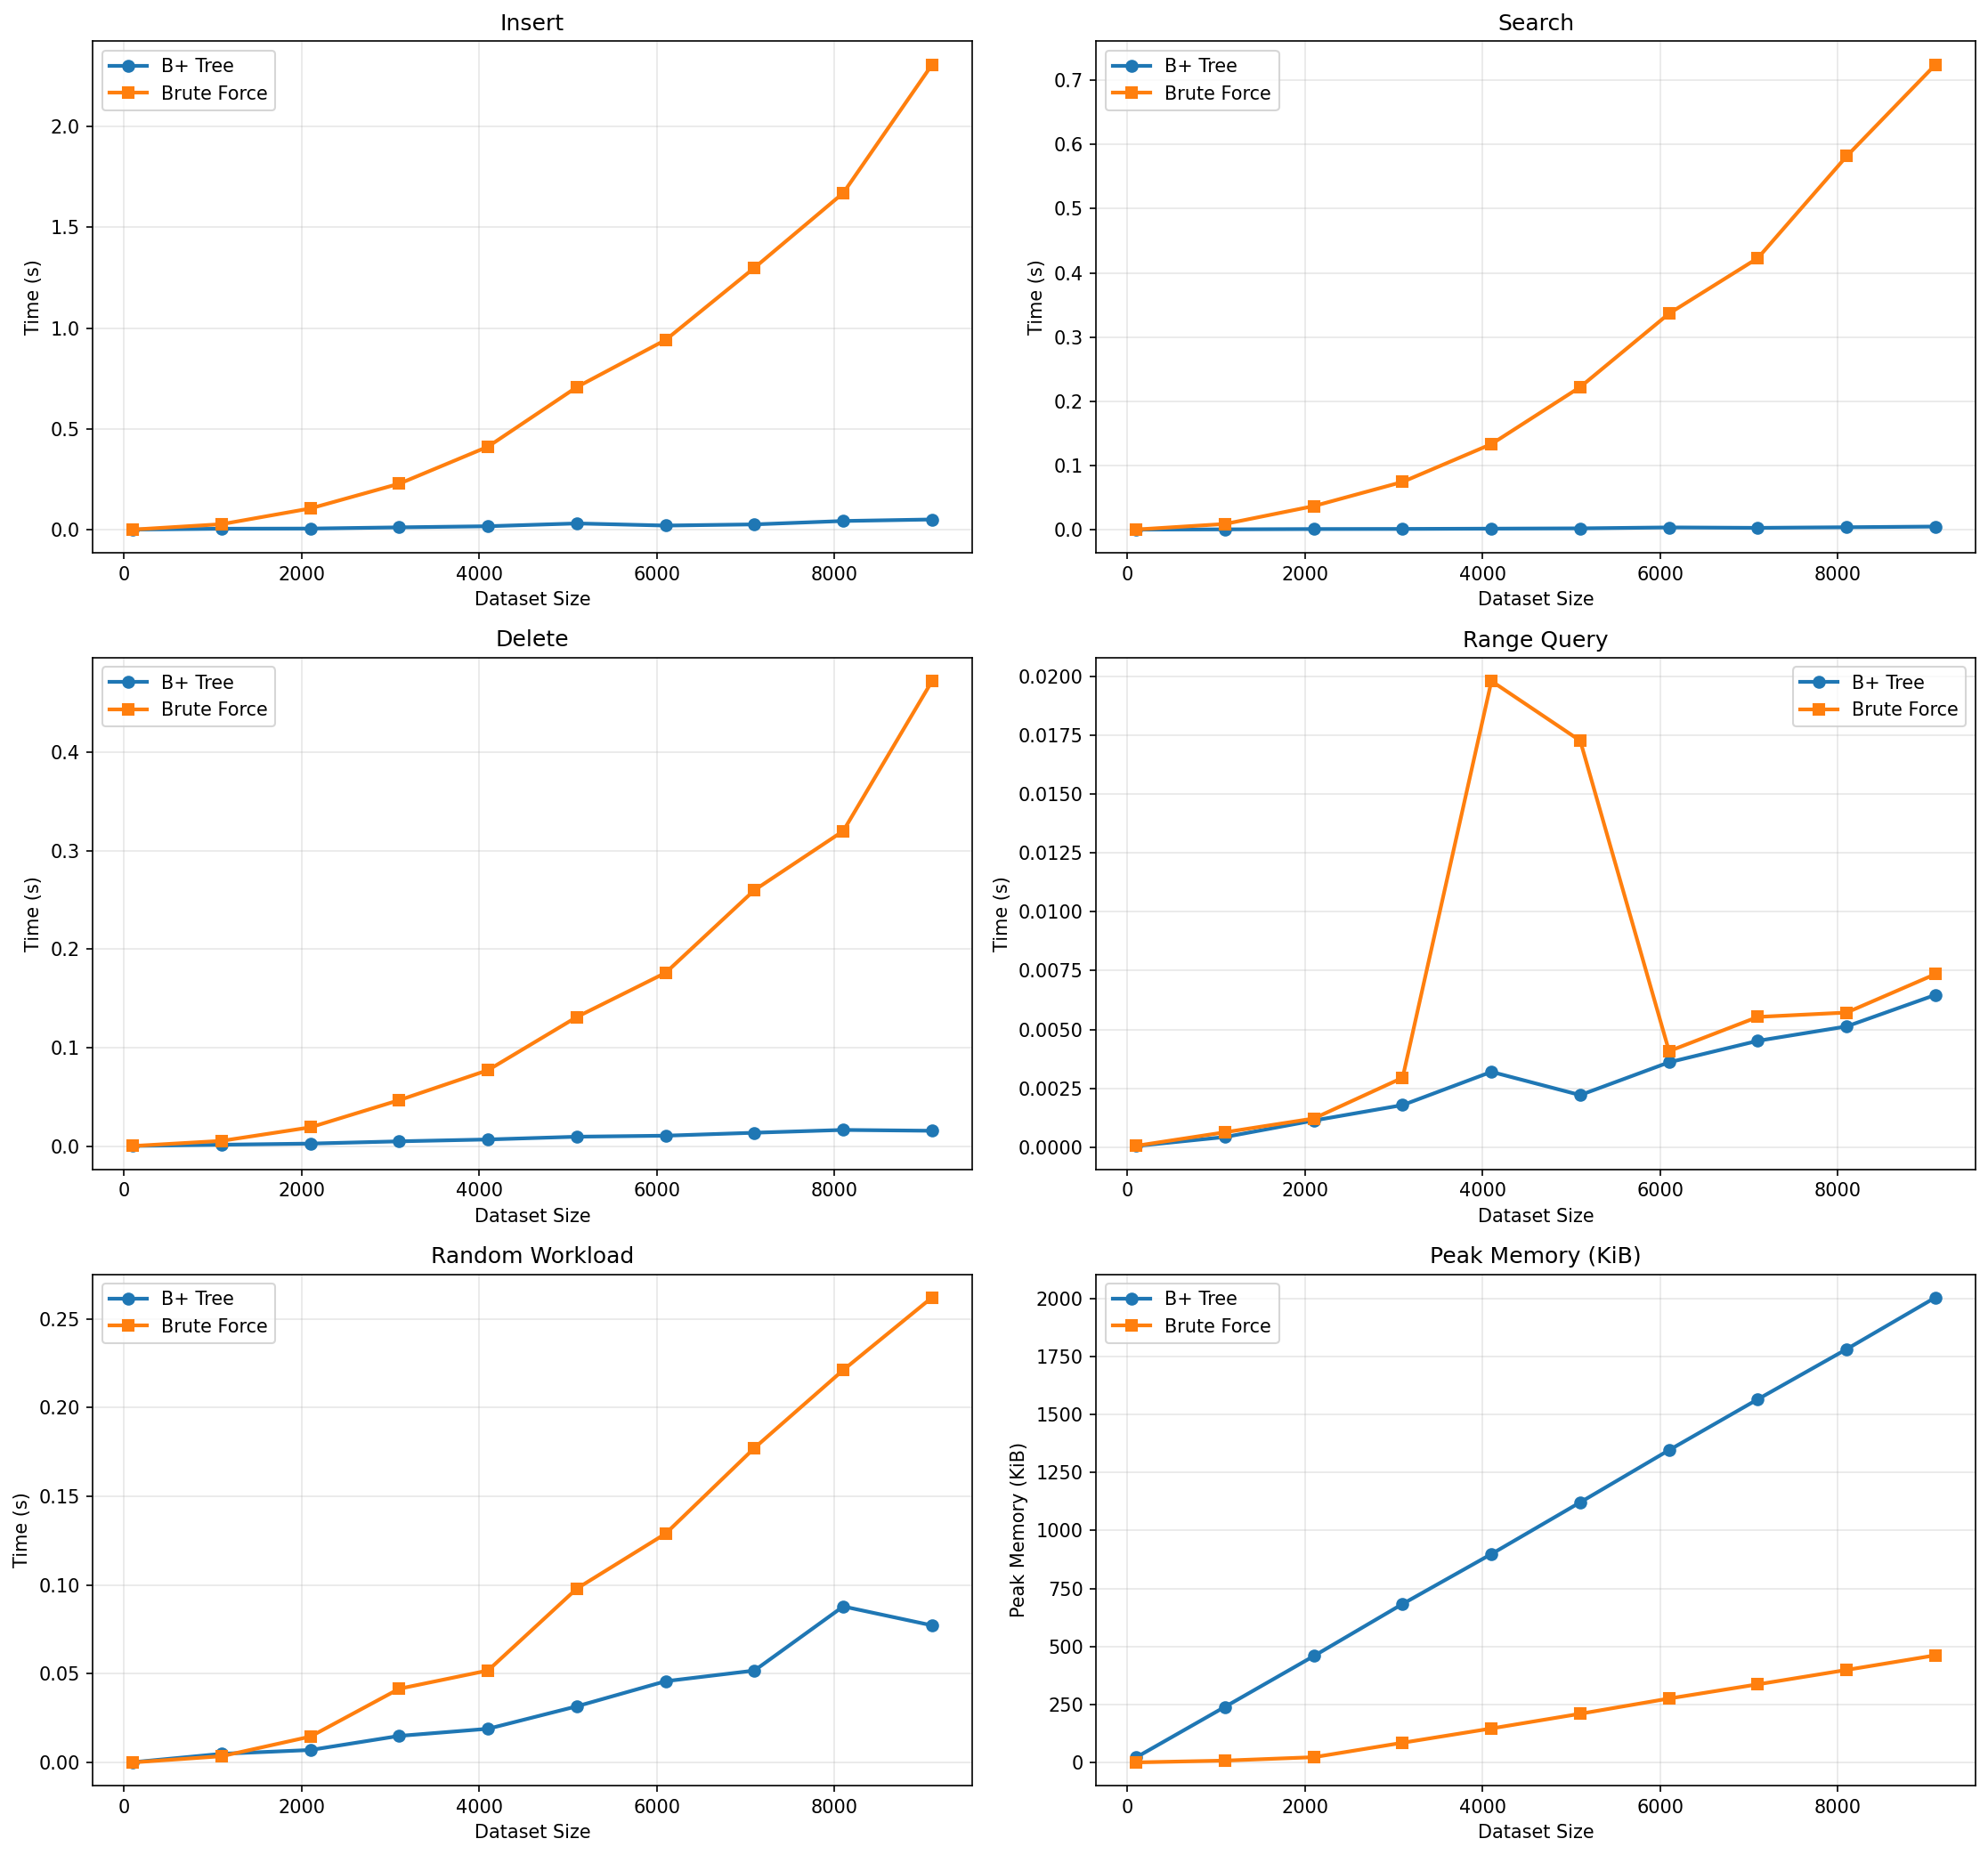

In [5]:
# Display performance plots inline (no folder writes)
results = benchmark_results['results']
sizes = [r['size'] for r in results]

series = [
    ('Insert', [r['bplustree']['insert_time_sec'] for r in results], [r['bruteforce']['insert_time_sec'] for r in results]),
    ('Search', [r['bplustree']['search_time_sec'] for r in results], [r['bruteforce']['search_time_sec'] for r in results]),
    ('Delete', [r['bplustree']['delete_time_sec'] for r in results], [r['bruteforce']['delete_time_sec'] for r in results]),
    ('Range Query', [r['bplustree']['range_query_time_sec'] for r in results], [r['bruteforce']['range_query_time_sec'] for r in results]),
    ('Random Workload', [r['bplustree']['random_workload_time_sec'] for r in results], [r['bruteforce']['random_workload_time_sec'] for r in results]),
    ('Peak Memory (KiB)', [r['bplustree']['peak_memory_bytes'] / 1024 for r in results], [r['bruteforce']['peak_memory_bytes'] / 1024 for r in results]),
]

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
for ax, (title, bplus_vals, brute_vals) in zip(axes.ravel(), series):
    ax.plot(sizes, bplus_vals, marker='o', linewidth=2, label='B+ Tree')
    ax.plot(sizes, brute_vals, marker='s', linewidth=2, label='Brute Force')
    ax.set_title(title)
    ax.set_xlabel('Dataset Size')
    ax.set_ylabel('Time (s)' if 'Memory' not in title else 'Peak Memory (KiB)')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
clear_output(wait=True)
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
display(Image(data=buf.getvalue()))
buf.close()
plt.close(fig)

### Performance Explanations and Findings

- **B+ Tree**
  - Insert, search, and delete operations are $O(\log n)$ due to tree traversal.
  - Range query is $O(\log n + k)$: $O(\log n)$ to find the start, $O(k)$ to collect $k$ results.
  - Peak memory is higher due to node and pointer overhead.
- **Brute Force**
  - All operations (insert, search, delete, range query) are $O(n)$, as they scan the list.
  - Peak memory is lower, storing only the data.
- **B+ tree peak memory higher than brute force**
  - B+ tree stores extra structure (nodes, pointers), while brute force is just a flat list.

**Findings:**
- Insert, search, delete, and random workloads are much faster in B+ tree than brute force.
- Range query times are often similar for both, especially for large ranges.
- Peak memory usage is higher for B+ tree compared to brute force.

## Visualisations (Graphviz)
This section renders B+ Tree structural diagrams showing:
- internal node hierarchy
- leaf node records
- leaf linkage through dashed `next` edges.

In [6]:
# Optional: install Python graphviz package if missing
# %pip install graphviz

**Graphviz note:** `dot` executable is not installed on PATH. Trying existing rendered images...

### Using existing rendered tree image: `c:\Users\Saharsh\Desktop\SEM 6\Git_Repos\College_Social_Media_DB\Module_A\database\visualizations\bplustree_demo.png`

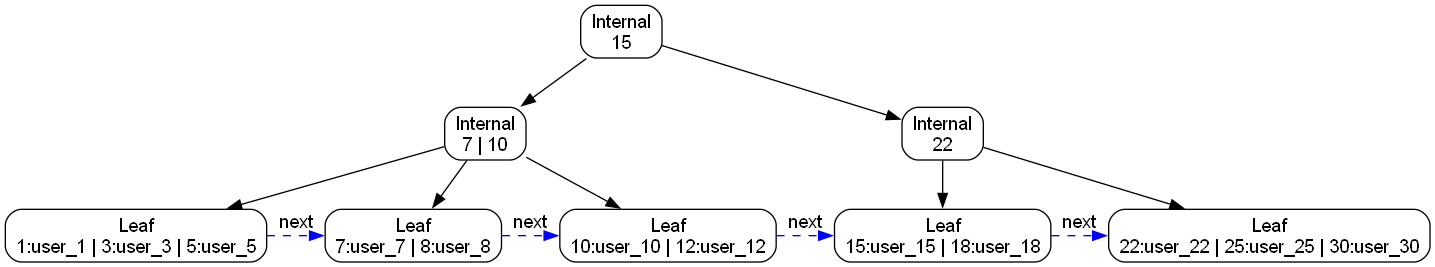

In [7]:
tree_for_viz = BPlusTree(order=4)
for k in [50, 10, 70, 20, 60, 80, 30, 40, 90, 100, 5, 15]:
    tree_for_viz.insert(k, f'rec_{k}')

dot = tree_for_viz.visualize_tree()
dot_path = shutil.which('dot')
if dot_path:
    png_bytes = dot.pipe(format='png')
    display(Image(data=png_bytes))
else:
    display(Markdown('**Graphviz note:** `dot` executable is not installed on PATH. Trying existing rendered images...'))
    candidate_paths = [
        viz_dir / 'report_bplustree.png',
        viz_dir / 'bplustree_demo.png',
        viz_dir / 'bplustree_demo_large.png',
    ]

    # Also scan for tree-related images produced in earlier runs
    candidate_paths.extend(sorted(viz_dir.glob('*bplustree*.png')))
    candidate_paths.extend(sorted(viz_dir.glob('*tree*.png')))

    jpg_dir = db_dir / 'performance_results_jpgs'
    if jpg_dir.exists():
        candidate_paths.extend(sorted(jpg_dir.glob('*bplustree*.jpg')))
        candidate_paths.extend(sorted(jpg_dir.glob('*tree*.jpg')))

    seen = set()
    existing = []
    for p in candidate_paths:
        s = str(p)
        if s in seen:
            continue
        seen.add(s)
        if p.exists() and p.is_file():
            existing.append(p)

    if existing:
        display(Markdown(f'### Using existing rendered tree image: `{existing[0]}`'))
        display(Image(filename=str(existing[0])))
    else:
        display(Markdown('### DOT Source (fallback)'))
        print(dot.source)

        # Text fallback for structure validation without Graphviz binaries
        from collections import deque
        q = deque([(tree_for_viz.root, 0)])
        levels = {}
        while q:
            node, depth = q.popleft()
            kind = 'Leaf' if node.is_leaf else 'Internal'
            levels.setdefault(depth, []).append(f"{kind}({', '.join(map(str, node.keys))})")
            if not node.is_leaf:
                for child in node.children:
                    q.append((child, depth + 1))

        display(Markdown('### Level-wise Tree View (fallback)'))
        for depth in sorted(levels):
            print(f"Level {depth}: {' | '.join(levels[depth])}")

        leaf = tree_for_viz._leftmost_leaf()
        chain = []
        while leaf is not None:
            chain.append('[' + ', '.join(f"{k}:{v}" for k, v in zip(leaf.keys, leaf.values)) + ']')
            leaf = leaf.next
        display(Markdown('### Leaf Chain (fallback)'))
        print(' -> '.join(chain))

## Conclusion
The B+ Tree implementation provides balanced indexing with efficient exact search and range retrieval through linked leaves. In benchmark results, B+ Tree performance generally scales better than brute force as dataset size increases, especially for search and range operations.

### Key Findings
- B+ Tree maintains sorted structure and supports predictable update/delete behavior under node split/merge operations.
- Automated benchmarking shows clear comparative trends for time and memory across operation types.
- Graphviz visualizations help validate structural correctness and leaf linkage.
- The table layer now includes explicit select and aggregation APIs (count/sum/min/max/avg).

### Challenges
- Correct deletion behavior (borrowing/merging + separator updates) is the most error-prone part.

### Video Link (to be added)
Paste your 3-5 minute demo video URL here before final submission.